# Jaguar Re-ID — CNN Improved v1

**Architecture** : 4x(Conv2D + BatchNorm + MaxPool2D) → GlobalAveragePooling2D → Dropout → Dense(128) → Dense(31)  
**Improvement over Baseline** : TODO

## 1. Setup & data loading

In [1]:
import sys, os
sys.path.insert(0, os.path.join(os.getcwd(), '..'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, optimizers, callbacks
from sklearn.preprocessing import normalize
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

from src.config import *
from src.data import load_data, load_test_pairs, make_dataset

os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(SUBMISSION_DIR, exist_ok=True)
os.makedirs(LOG_DIR, exist_ok=True)

tf.random.set_seed(SEED)
np.random.seed(SEED)

print(f"TensorFlow: {tf.__version__}")
print(f"GPU: {tf.config.list_physical_devices('GPU')}")

I0000 00:00:1775775577.769489 3869396 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1775775577.846345 3869396 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1775775579.880327 3869396 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


TensorFlow: 2.21.0
GPU: []


E0000 00:00:1775775580.637364 3869396 cuda_executor.cc:1737] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1775775580.637995 3869512 cuda_executor.cc:1755] Failed to determine cuDNN version (Note that this is expected if the application doesn't link the cuDNN plugin): INTERNAL: cuDNN error: CUDNN_STATUS_INTERNAL_ERROR
E0000 00:00:1775775580.683532 3869396 cuda_executor.cc:1737] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1775775580.683637 3869512 cuda_executor.cc:1755] Failed to determine cuDNN version (Note that this is expected if the application doesn't link the cuDNN plugin): INTERNAL: cuDNN error: CUDNN_STATUS_INTERNAL_ERROR
W0000 00:00:1775775580.700470 3869396 gpu_device.cc:2365] Cannot dlopen some GPU l

In [2]:
MODEL_NAME   = 'cnn_improved_v1'
AUGMENTATION = 'moderate'
#   'none'     → raw images
#   'light'    → flip horizontal
#   'moderate' → flip + brightness + contrast
#   'heavy'    → flip + rotation + zoom + brightness + contrast

In [3]:
X_train, y_train = load_data('train')
X_val, y_val     = load_data('val')
test_pairs_df = load_test_pairs()

train_ds = make_dataset(X_train, y_train, training=True, augmentation=AUGMENTATION)
val_ds   = make_dataset(X_val, y_val)

print(f"Train: {X_train.shape} | Val: {X_val.shape}")
print(f"Train batches: {len(train_ds)} | Val batches: {len(val_ds)}")

Train: (1516, 224, 224, 3) | Val: (379, 224, 224, 3)
Train batches: 48 | Val batches: 12


## 2. Model architecture

In [4]:
def build_model():
    model = keras.Sequential([
        layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3)),

        layers.Conv2D(32, 3, activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2),

        layers.Conv2D(64, 3, activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2),

        layers.Conv2D(128, 3, activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2),

        layers.Conv2D(256, 3, activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2),

        layers.GlobalAveragePooling2D(),
        layers.Dropout(0.3),
        layers.Dense(128, activation='relu'),
        layers.Dense(NUM_CLASSES, activation='softmax')
    ], name=MODEL_NAME)
    return model

model = build_model()
model.summary()

Model: "cnn_improved_v1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 31)             │         3,999 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 427,231 (1.63 MB)

 Trainable params: 426,271 (1.63 MB)

 Non-trainable params: 960 (3.75 KB)

## 3. Hyperparameter sweep

On teste plusieurs learning rates, on garde le meilleur.

In [ ]:
def train_and_eval(lr, run_name):
    m = build_model()
    m.compile(
        optimizer=optimizers.Adam(learning_rate=lr),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    log_dir = os.path.join(LOG_DIR, MODEL_NAME, run_name)
    hist = m.fit(
        train_ds,
        validation_data=val_ds,
        epochs=100,
        callbacks=[
            callbacks.EarlyStopping(
                monitor='val_loss', patience=5, restore_best_weights=True
            ),
            callbacks.ReduceLROnPlateau(
                monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=0
            ),
            callbacks.TensorBoard(log_dir=log_dir),
        ],
        verbose=0
    )
    _, val_acc = m.evaluate(val_ds, verbose=0)
    best_epoch = np.argmin(hist.history['val_loss']) + 1
    print(f"  {run_name}: val_acc={val_acc:.4f} (best epoch={best_epoch})")
    return {'val_acc': val_acc, 'best_epoch': best_epoch, 'hist': hist.history}

In [6]:
lr_candidates = [1e-2, 1e-3, 1e-4]

results = {}
print(f"=== LR sweep ({MODEL_NAME}) ===")
for lr in lr_candidates:
    run_name = f'lr_{lr}'
    results[run_name] = train_and_eval(lr, run_name)

=== LR sweep (cnn_improved_v1) ===


  lr_0.01: val_acc=0.1108 (best epoch=5)
  lr_0.001: val_acc=0.0475 (best epoch=1)
  lr_0.0001: val_acc=0.0897 (best epoch=1)


In [7]:
rows = [{'Config': name, 'Val Accuracy': r['val_acc'], 'Best Epoch': r['best_epoch']}
        for name, r in results.items()]
results_df = pd.DataFrame(rows).sort_values('Val Accuracy', ascending=False).reset_index(drop=True)
display(results_df)

BEST_CONFIG = results_df.iloc[0]['Config']
BEST_LR = float(BEST_CONFIG.split('_')[1])
BEST_EPOCH = int(results_df.iloc[0]['Best Epoch'])
print(f"\nBest: {BEST_CONFIG} \u2192 val_acc={results_df.iloc[0]['Val Accuracy']:.4f}")

,Config,Val Accuracy,Best Epoch
0,lr_0.01,0.110818,5
1,lr_0.0001,0.089710,1
2,lr_0.001,0.047493,1



Best: lr_0.01 → val_acc=0.1108


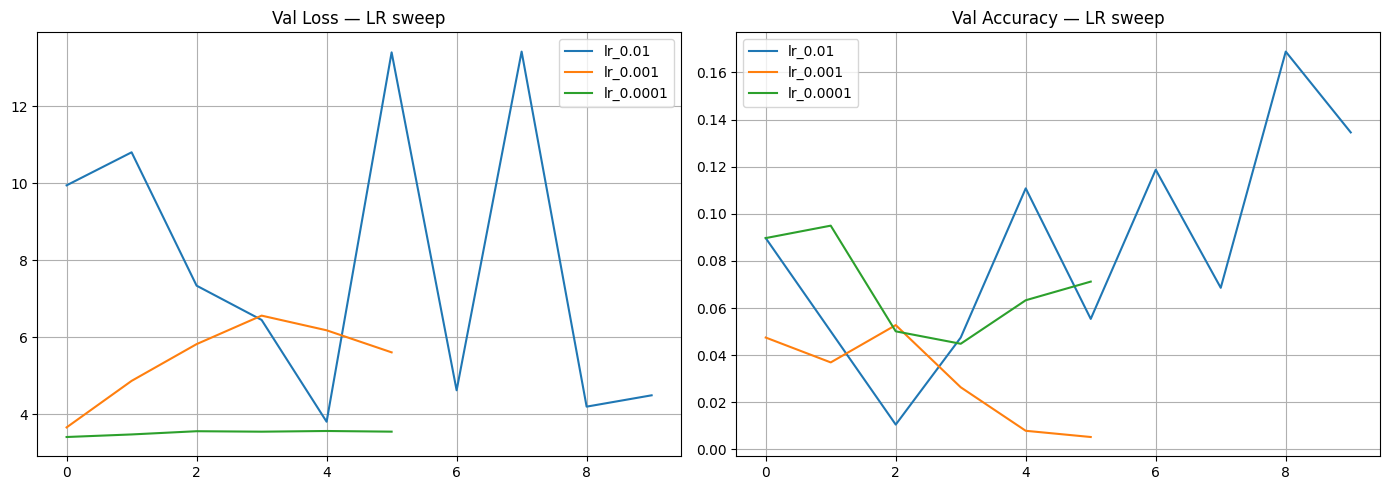

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for name, r in results.items():
    axes[0].plot(r['hist']['val_loss'],     label=name)
    axes[1].plot(r['hist']['val_accuracy'], label=name)
axes[0].set_title('Val Loss \u2014 LR sweep'); axes[0].legend(); axes[0].grid(True)
axes[1].set_title('Val Accuracy \u2014 LR sweep'); axes[1].legend(); axes[1].grid(True)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, f'{MODEL_NAME}_lr_sweep.png'), dpi=150, bbox_inches='tight')
plt.show()

## 4. Evaluation (best config)

In [9]:
model = build_model()
model.compile(
    optimizer=optimizers.Adam(learning_rate=BEST_LR),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
log_dir = os.path.join(LOG_DIR, MODEL_NAME, f'best_{datetime.now().strftime("%Y%m%d-%H%M%S")}')

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=100,
    callbacks=[
        callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
        callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=1),
        callbacks.TensorBoard(log_dir=log_dir, histogram_freq=1),
    ],
    verbose=1
)

Epoch 1/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 77s 2s/step - accuracy: 0.1102 - loss: 3.1914 - val_accuracy: 0.0580 - val_loss: 25.1801 - learning_rate: 0.0100
Epoch 2/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 74s 2s/step - accuracy: 0.1880 - loss: 2.8278 - val_accuracy: 0.0765 - val_loss: 17.6814 - learning_rate: 0.0100
Epoch 3/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 73s 2s/step - accuracy: 0.2328 - loss: 2.6283 - val_accuracy: 0.1161 - val_loss: 5.6135 - learning_rate: 0.0100
Epoch 4/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 72s 2s/step - accuracy: 0.2586 - loss: 2.5366 - val_accuracy: 0.0871 - val_loss: 11.8862 - learning_rate: 0.0100
Epoch 5/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 73s 2s/step - accuracy: 0.3021 - loss: 2.3560 - val_accuracy: 0.1821 - val_loss: 3.1524 - learning_rate: 0.0100
Epoch 6/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 72s 1s/step - accuracy: 0.3450 - loss: 2.2387 - val_accuracy: 0.1451 - val_loss: 3.7819 - learning_rate: 0.0100
Epoch 7/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 74s 2s/step - accuracy: 0.3780 - loss: 2.1304 - val_

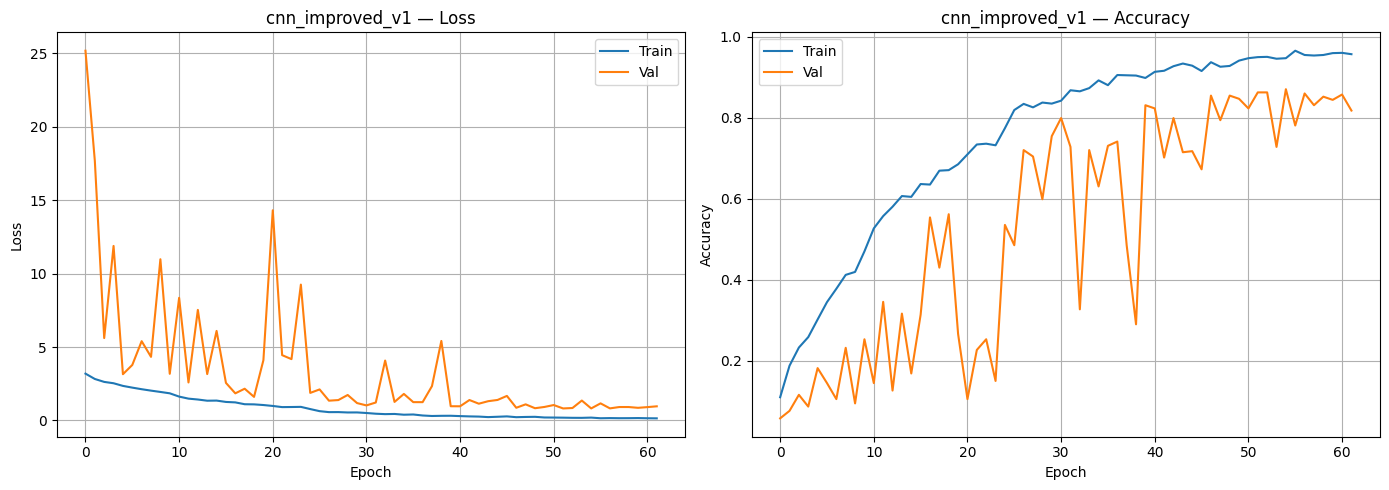

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['loss'],     label='Train')
axes[0].plot(history.history['val_loss'], label='Val')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].set_title(f'{MODEL_NAME} \u2014 Loss'); axes[0].legend(); axes[0].grid(True)

axes[1].plot(history.history['accuracy'],     label='Train')
axes[1].plot(history.history['val_accuracy'], label='Val')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
axes[1].set_title(f'{MODEL_NAME} \u2014 Accuracy'); axes[1].legend(); axes[1].grid(True)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, f'{MODEL_NAME}_history.png'), dpi=150, bbox_inches='tight')
plt.show()

In [11]:
train_loss, train_acc = model.evaluate(train_ds, verbose=0)
val_loss, val_acc     = model.evaluate(val_ds, verbose=0)

print(f"{MODEL_NAME} (best LR={BEST_LR}):")
print(f"  Train \u2014 Loss: {train_loss:.4f}, Acc: {train_acc:.4f}")
print(f"  Val   \u2014 Loss: {val_loss:.4f}, Acc: {val_acc:.4f}")

cnn_improved_v1 (best LR=0.01):
  Train — Loss: 0.0720, Acc: 0.9861
  Val   — Loss: 0.8210, Acc: 0.8628


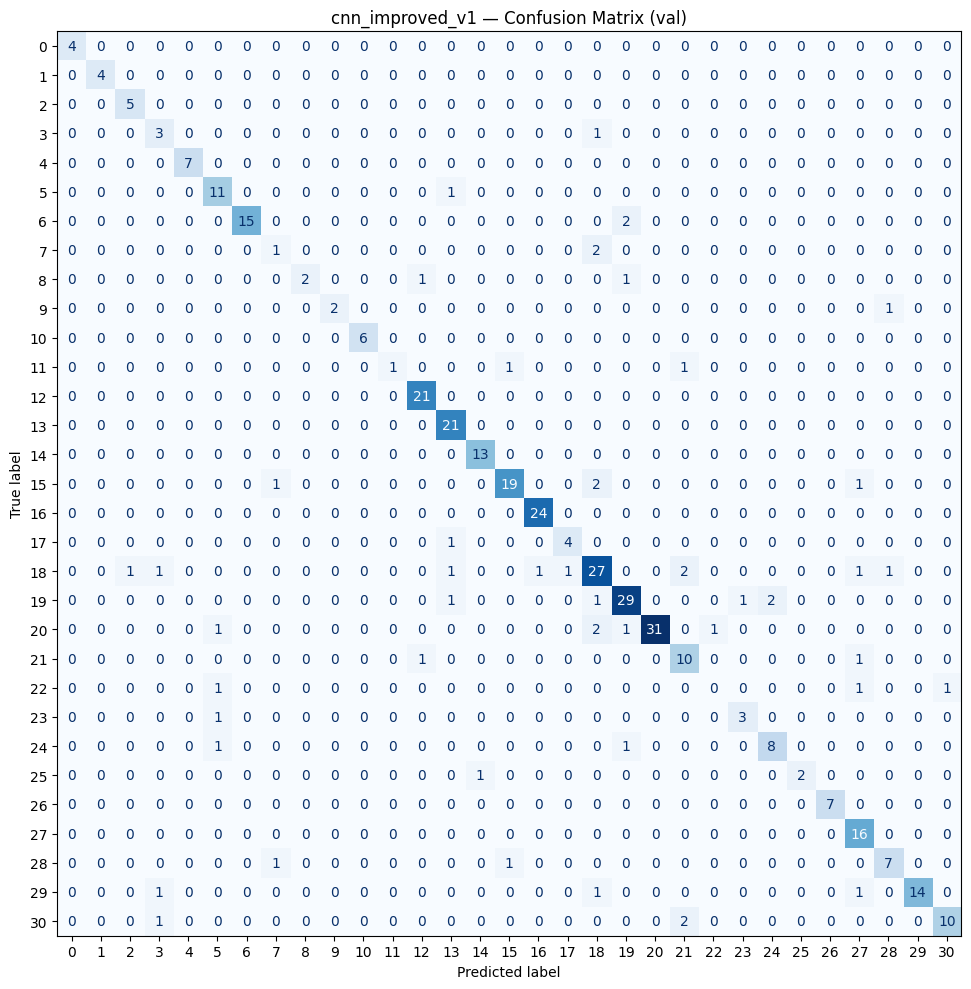

In [12]:
y_val_pred = model.predict(val_ds, verbose=0).argmax(axis=1)

cm = confusion_matrix(y_val, y_val_pred)
fig, ax = plt.subplots(figsize=(12, 10))
ConfusionMatrixDisplay(cm).plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title(f'{MODEL_NAME} \u2014 Confusion Matrix (val)')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, f'{MODEL_NAME}_confusion.png'), dpi=150, bbox_inches='tight')
plt.show()

## 5. Kaggle submission

In [13]:
X_all = np.concatenate([X_train, X_val])
y_all = np.concatenate([y_train, y_val])
all_ds = make_dataset(X_all, y_all, training=True, augmentation=AUGMENTATION)

print(f"Retraining on full dataset ({len(X_all)} images) for {BEST_EPOCH} epochs")

final_model = build_model()
final_model.compile(
    optimizer=optimizers.Adam(learning_rate=BEST_LR),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

final_log = os.path.join(LOG_DIR, MODEL_NAME, f'final_{datetime.now().strftime("%Y%m%d-%H%M%S")}')
final_model.fit(
    all_ds, epochs=BEST_EPOCH,
    callbacks=[callbacks.TensorBoard(log_dir=final_log)],
    verbose=1
)
print(f"Final train acc: {final_model.evaluate(all_ds, verbose=0)[1]:.4f}")

Retraining on full dataset (1895 images) for 5 epochs
Epoch 1/5
60/60 ━━━━━━━━━━━━━━━━━━━━ 94s 1s/step - accuracy: 0.1298 - loss: 3.1562
Epoch 2/5
60/60 ━━━━━━━━━━━━━━━━━━━━ 88s 1s/step - accuracy: 0.1984 - loss: 2.7575
Epoch 3/5
60/60 ━━━━━━━━━━━━━━━━━━━━ 89s 1s/step - accuracy: 0.2232 - loss: 2.6167
Epoch 4/5
60/60 ━━━━━━━━━━━━━━━━━━━━ 88s 1s/step - accuracy: 0.2881 - loss: 2.4145
Epoch 5/5
60/60 ━━━━━━━━━━━━━━━━━━━━ 88s 1s/step - accuracy: 0.3219 - loss: 2.2823
Final train acc: 0.1066


In [14]:
X_test, test_filenames = load_data('test')

inp = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x = inp
for layer in final_model.layers[:-1]:
    x = layer(x)
embedding_model = keras.Model(inputs=inp, outputs=x, name=f'{MODEL_NAME}_embedding')

test_embeddings = embedding_model.predict(X_test, batch_size=BATCH_SIZE, verbose=1)
test_embeddings_norm = normalize(test_embeddings, axis=1)
print(f"Embedding shape: {test_embeddings_norm.shape}")

del X_test  # free memory

fname_to_idx = {fname: i for i, fname in enumerate(test_filenames)}
query_idx   = test_pairs_df['query_image'].map(fname_to_idx).values
gallery_idx = test_pairs_df['gallery_image'].map(fname_to_idx).values

# Chunked to avoid OOM on high-dim embeddings
CHUNK = 1000
similarities = np.empty(len(query_idx), dtype=np.float32)
for start in range(0, len(query_idx), CHUNK):
    sl = slice(start, start + CHUNK)
    q = test_embeddings_norm[query_idx[sl]]
    g = test_embeddings_norm[gallery_idx[sl]]
    similarities[sl] = np.clip((q * g).sum(axis=1), 0, 1)

submission = pd.DataFrame({'row_id': test_pairs_df['row_id'], 'similarity': similarities})
submission_path = os.path.join(SUBMISSION_DIR, f'submission_{MODEL_NAME}.csv')
submission.to_csv(submission_path, index=False)
print(f"Saved: {submission_path}")
display(submission.head())

12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 169ms/step
Embedding shape: (371, 128)
Saved: /HomeSweetHome/FHuang5/Developer/kaggle_jaguar_classification/submissions/submission_cnn_improved_v1.csv


,row_id,similarity
0,0,0.999058
1,1,0.990836
2,2,0.987953
3,3,0.986669
4,4,0.993853


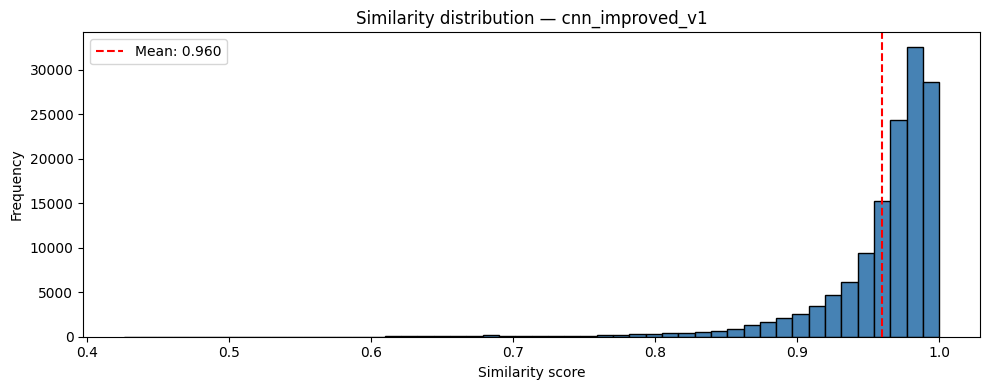

In [15]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(similarities, bins=50, color='steelblue', edgecolor='black')
ax.axvline(similarities.mean(), color='red', linestyle='--', label=f'Mean: {similarities.mean():.3f}')
ax.set_xlabel('Similarity score'); ax.set_ylabel('Frequency')
ax.set_title(f'Similarity distribution \u2014 {MODEL_NAME}')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, f'{MODEL_NAME}_similarity.png'), dpi=150, bbox_inches='tight')
plt.show()

## 6. Observations & Verdict

### Résultats

| Metrique | Train | Val |
|----------|-------|-----|
| Accuracy | 0.9861 | 0.8628 |
| Loss     | 0.0720 | 0.8210 |
| Overfitting ? | — | Modéré |
| Kaggle Score (public) | — | 0.171 |
| Kaggle Score (private) | — | TODO |

*Note : Les métriques Train/Val viennent de la Section 4 (patience=10). Le score Kaggle vient de la Section 5 qui a retrain pour seulement 5 epochs (best_epoch faussé par le sweep).*

### Analyse des hyperparamètres

**Hyperparamètres du modèle :**

- **Structure (4 blocs Conv2D + BN + MaxPool → GAP → Dropout → Dense(128) → Dense(31))** : On ajoute un 4e bloc conv (256 filtres) par rapport au baseline (3 blocs). Les feature maps passent de 28×28 à 14×14, permettant de capturer des features plus abstraites. La Section 4 valide cette architecture avec val_acc=86.3%, le meilleur résultat de tous nos modèles.

- **BatchNormalization** : Ajouté après chaque Conv2D pour normaliser les activations. En théorie, cela stabilise l'entraînement et permet un LR plus agressif. **En pratique, le BN a interagi négativement avec la patience réduite du sweep (5/3)** : les running statistics (mean/variance mobiles) ont besoin de ~15-20 epochs pour se stabiliser, mais l'EarlyStopping coupait après ~10 epochs. Le `evaluate()` du sweep utilisait des running stats non-convergées, faussant complètement les résultats du sweep (11%, 4.7%, 8.9%). La Section 4 avec patience=10 prouve que le BN fonctionne bien quand on lui laisse le temps.

- **Dropout (0.3)** : Ajouté entre GAP et Dense(128). Éteint aléatoirement 30% des neurones pendant le training, forçant le réseau à ne pas trop dépendre d'un seul filtre. Contribue à la régularisation — le gap train/val de la Section 4 (98.6% vs 86.3% = ~12 pts) est raisonnable malgré l'augmentation de capacité.

- **Fonctions d'activation (relu + softmax)** : Inchangées par rapport au baseline. ReLU reste approprié pour 4 blocs conv — le BN aide à éviter le vanishing gradient sur les couches profondes.

- **Data augmentation (moderate : flip + brightness + contrast)** : Première utilisation de l'augmentation dans le projet. **Bug découvert et corrigé** : `RandomBrightness(0.2)` dans `src/data.py` utilisait `value_range=(0, 255)` par défaut, alors que nos images sont normalisées en [0, 1]. L'offset appliqué était de ±51 sur des valeurs entre 0 et 1, détruisant complètement les images. Le premier run a collapsé à 9.5% à cause de ce bug. Fix : ajout de `value_range=(0.0, 1.0)`. Ce bug montre l'importance de vérifier les valeurs par défaut des layers Keras, surtout quand le preprocessing diffère des conventions standard (0-255).

**Paramètres d'apprentissage :**

- **Learning rate** : Le sweep étant faussé par le BN (voir ci-dessus), le "best LR" sélectionné (0.01) est incorrect. La Section 4 avec lr=0.01 et patience=10 obtient 86.3% — en réalité lr=0.01 fonctionne mieux ici que dans le baseline (où il collapse) grâce au BatchNorm qui stabilise les gradients. Le BN permet d'utiliser un LR plus agressif, exactement comme prévu en théorie.

- **EarlyStopping (patience=5) et ReduceLROnPlateau (patience=3)** : **C'est le paramètre qui a causé l'échec du Kaggle score.** La patience réduite (5/3 au lieu de 10/5) avait été mise en place dans le baseline pour accélérer le sweep sur CPU. Mais avec le BatchNorm, les running statistics ont besoin de plus d'epochs pour converger. Le sweep a donc reporté des val_acc aberrantes (11%, 4.7%, 8.9%) et sélectionné best_epoch=5, causant un retrain final de seulement 5 epochs → train_acc=10.7% → Kaggle 0.171. **Leçon : la patience du sweep doit être adaptée à l'architecture, pas fixée arbitrairement.**

- **Optimizer (Adam)** et **Batch size (32)** : Inchangés par rapport au baseline. Adam reste approprié, le batch size par défaut est suffisant.

**Overfitting :**

D'après la Section 4 (seule section fiable), gap train/val de ~12 pts (98.6% vs 86.3%). Plus élevé que le CNN baseline (~9 pts), ce qui est attendu vu l'augmentation de capacité (4 blocs + 256 filtres). Le Dropout(0.3) et l'augmentation moderate aident à contenir l'overfitting.

### Verdict

- [x] Improvable → L'architecture est validée par la Section 4 (val_acc=86.3%, meilleur résultat du projet). Le seul fix nécessaire pour v2 : remonter la patience du sweep à 10/5 (valeurs par défaut du template) pour que le BatchNorm ait le temps de stabiliser ses running statistics. Architecture identique pour v2.

### Interprétation

Ce notebook a mis en lumière deux enseignements importants sur les hyperparamètres : (1) le `value_range` de `RandomBrightness` doit correspondre au preprocessing des images — un paramètre par défaut incorrect a causé un collapse total ; (2) la **patience de l'EarlyStopping interagit fortement avec le BatchNormalization** — une patience trop courte empêche les running statistics de converger, faussant l'évaluation et le choix du best_epoch. La Section 4 prouve que l'architecture 4-blocs + BN + Dropout + augmentation est la meilleure jusqu'ici (86.3% val_acc). Le fix pour v2 est simple : remonter la patience du sweep.